# Interactive Exercise: Plot Historical Expenditures

This exercise uses Illinois General Funds expenditure data from CGFA to create simple line and bar charts.

You will:

1. Load the data.
2. Select one expenditure series.
3. Reshape the data for plotting.
4. Create a line chart.
5. Create a bar chart.

In [1]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)

Warning message:
“package ‘readr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
df <- read_csv("/Users/alishasaini/Library/CloudStorage/Box-Box/2027/jupyter_book/state-expenditure-forecasting-guidebook/data/illinois_expenditures.csv")

df

Rows: 14 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): series, label
dbl (10): fy16, fy17, fy18, fy19, fy20, fy21, fy22, fy23, fy24, fy25

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


series,label,fy16,fy17,fy18,fy19,fy20,fy21,fy22,fy23,fy24,fy25
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
education,State Board of Education,6507,7211,8201,8376,8886,8873,9274,9756,10349,10807
healthcare,Healthcare and Family Services,6090,5972,7601,7633,6743,7548,7810,8476,9959,9143
human_services,Human Services,3153,3283,3640,3740,4001,4228,4456,5407,6547,7278
teacher_pensions,Teachers' Retirement System,3851,4096,4210,4592,4946,5278,5838,6001,6109,6318
higher_education,Higher Education Agencies,2039,3359,3141,3226,3578,3747,4174,4169,4432,4571
central_management,Central Management Services,28,182,1960,2101,2082,2078,2852,1906,2094,2391
state_employee_pensions,State Employees Retirement System,1367,1309,1319,1395,1638,1705,1721,1698,1775,2021
corrections,Corrections,888,1076,1890,1519,1490,1502,1523,1725,1837,1893
aging,Aging,646,590,893,919,984,1055,1132,1289,1437,1627


In [4]:
selected_series <- "education"

In [8]:
plot_df <- df %>%
  filter(series == selected_series) %>%
  pivot_longer(
    cols = starts_with("fy"),
    names_to = "fiscal_year",
    values_to = "expenditure"
  ) %>%
  mutate(
    fiscal_year = as.numeric(gsub("fy", "", fiscal_year))
  )

plot_df

series,label,fiscal_year,expenditure
<chr>,<chr>,<dbl>,<dbl>
education,State Board of Education,16,6507
education,State Board of Education,17,7211
education,State Board of Education,18,8201
education,State Board of Education,19,8376
education,State Board of Education,20,8886
education,State Board of Education,21,8873
education,State Board of Education,22,9274
education,State Board of Education,23,9756
education,State Board of Education,24,10349


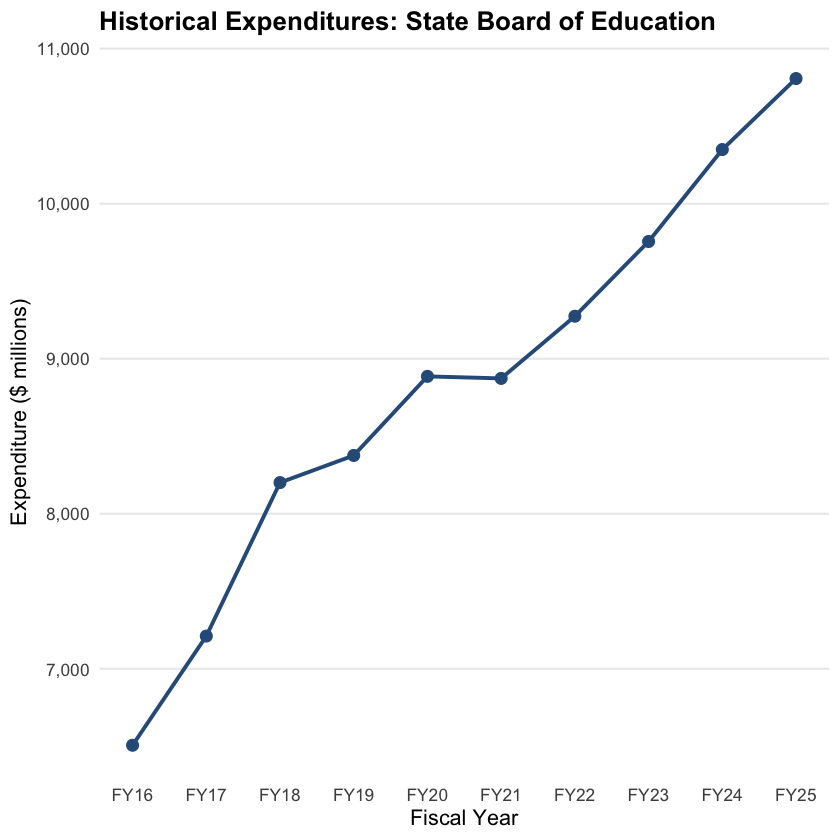

In [15]:
line_plot <-ggplot(plot_df,
       aes(x = fiscal_year, y = expenditure)) +
  geom_line(linewidth = 1.1, color = "#2F5D8A") +
  geom_point(size = 3, color = "#2F5D8A") +
  scale_x_continuous(
    breaks = plot_df$fiscal_year,
    labels = paste0("FY", plot_df$fiscal_year)
  ) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = paste("Historical Expenditures:", unique(plot_df$label)),
    x = "Fiscal Year",
    y = "Expenditure ($ millions)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  )

line_plot

In [21]:
ggsave(
  "/Users/alishasaini/Library/CloudStorage/Box-Box/2027/jupyter_book/state-expenditure-forecasting-guidebook/images/education_line_plot.png",
  plot = line_plot,
  width = 7,
  height = 4.5,
  dpi = 300
)

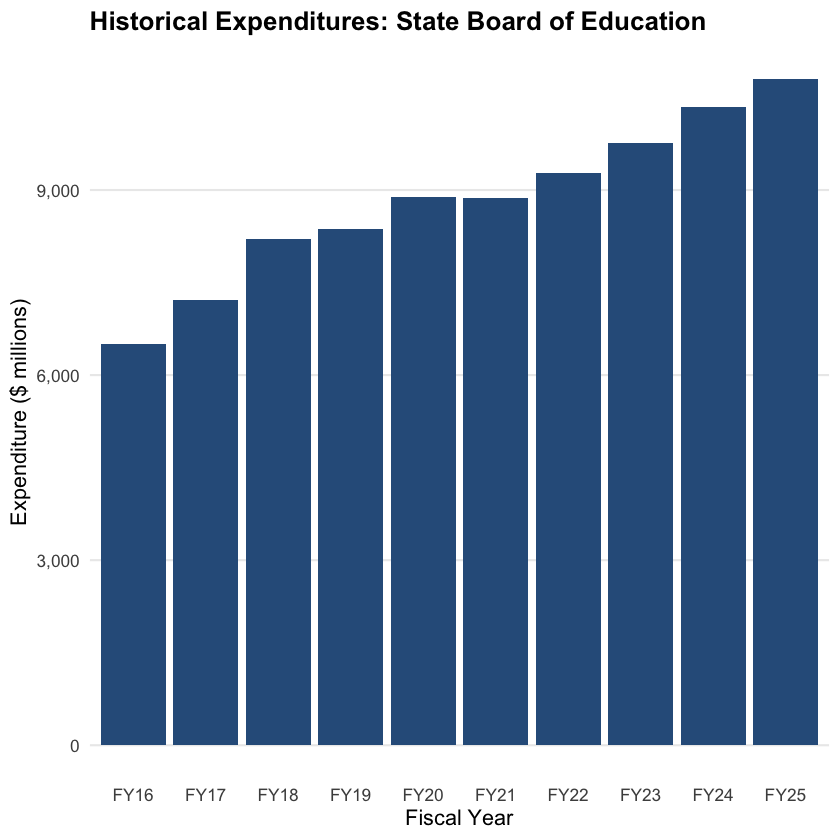

In [22]:
bar_plot <- ggplot(plot_df,
       aes(x = factor(fiscal_year,
                      levels = fiscal_year,
                      labels = paste0("FY", fiscal_year)),
           y = expenditure)) +
  geom_col(fill = "#2F5D8A") +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = paste("Historical Expenditures:", unique(plot_df$label)),
    x = "Fiscal Year",
    y = "Expenditure ($ millions)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  )

bar_plot

In [23]:
ggsave(
  "/Users/alishasaini/Library/CloudStorage/Box-Box/2027/jupyter_book/state-expenditure-forecasting-guidebook/images/education_bar_plot.png",
  plot = bar_plot,
  width = 7,
  height = 4.5,
  dpi = 300
)

## Try It Yourself

Change the value of `selected_series` and rerun the notebook.

Try:

- `healthcare`
- `human_services`
- `corrections`
- `higher_education`
- `total_expenditures`

Questions:

1. Which series appears most stable?
2. Which series has the largest jump?
3. Which chart is easier to interpret: the line chart or the bar chart?